# **SPECTRA testing notebook**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import argparse
import yaml
import pickle
import torch
import networkx as nx
import scanpy as sc
import numpy as np
import pandas as pd
import warnings
import os
import anndata as ad

ad.settings.allow_write_nullable_strings = True

# Suppress annoying warnings for a clean console
warnings.filterwarnings("ignore")

In [3]:
# torch device setting
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(torch.version.cuda)
    print(torch.cuda.get_device_name())
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

12.1
Tesla V100-SXM2-32GB
Using device: cuda


In [4]:
from spectra.utils import set_seed
from spectra.data import data_preprocessing, build_model_dataloaders_perts_split, compute_weights
from spectra.model import SPECTRA

### **Load config file**

In [5]:
config_path = '../configs/vcc_config_3layers.yaml'

with open(config_path, 'r') as file:
    config = yaml.safe_load(file)
print(yaml.dump(config, indent=2, sort_keys=False, default_flow_style=False))

project:
  name: SPECTRA_vcc_3layers
  seed: 42
  deterministic: false
  use_wandb: true
data:
  adata_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/adata_vcc.h5ad
  gene_list_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/gene_list-vcc.txt
  network_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/FUNGI_new_vcc.tsv
  scgpt_embeddings_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/scGPT_embeddings_all_genes.pkl
  gene_weights_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/gene_weights-vcc.pkl
model:
  architecture: reduced_encoder
  conv_type: FAGCN
  residual_weight: 0.7
  n_channels: 64
  dropout_p: 0.3
  num_node_features: 1
training:
  batch_size: 16
  lr: 0.001
  n_epochs: 20
  alpha: 1.8
  beta: 0.01
  gamma: 2.6
  eta: 3.3
  test_ratio: 0.2
  val_ratio: 0.1



In [6]:
# Initialization & Seeding - set it to deterministic for reproducibility
set_seed(seed=config['project']['seed'], deterministic=config['project']['deterministic'])

### **Load files**

In [7]:
# Load adata
adata = sc.read_h5ad(config['data']['adata_path'])
adata = data_preprocessing(adata,
    logtransform=True, 
    min_cells_per_pert=100)
adata

View of AnnData object with n_obs × n_vars = 220998 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

In [8]:
# scGPT gene embeddings
with open(config['data']['scgpt_embeddings_path'], "rb") as f:
    scgpt_dict = pickle.load(f)

In [9]:
# load GRN
network_data = pd.read_csv(config['data']['network_path'], sep='\t')
G = nx.DiGraph()
for _, edge in network_data.iterrows():
    G.add_edge(edge['source'], edge['target'], weight=edge['weight'])

G.remove_nodes_from([n for n in G.nodes if n not in scgpt_dict])
grn_genes = set(G.nodes)

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)

Number of nodes: 4914
Number of edges: 169075


In [10]:
# Filter adata to match final network genes
gene_list = grn_genes & set(adata.var_names)
if grn_genes != gene_list:
    print('WARNING: some genes in the provided gene list are not included in the grn, or the gene embeddings are missing; filtering them out...')
adata = adata[:, adata.var_names.isin(gene_list)]

In [11]:
# Filter out perturbations that aren't in the gene list
perturbations = list(adata.obs['target_gene'].unique())
perturbations.remove('non-targeting')
perts_not_included = list({
    pert for pert in perturbations
    if any(single_pert not in gene_list for single_pert in pert.split('+'))
})
if len(perts_not_included)>0:
    print(print('WARNING: some perturbed genes are not included in the GRN. Filtering these perturbation samples out...'))
adata = adata[~adata.obs['target_gene'].isin(perts_not_included)].copy()

None


### **Edge indices, embeddings matrix**
Other preparation steps fro SPECTRA

In [12]:
# shuffle data, sanity check
adata = adata[np.random.permutation(adata.n_obs), :]
assert set(G.nodes) == set(adata.var_names), "Nodes in G and adata.var_names differ!"

In [13]:
# Map Edge Index
gene_to_idx = {node: i for i, node in enumerate(adata.var_names)}
edges = [(gene_to_idx[u], gene_to_idx[v]) for u, v in G.edges()]
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

In [14]:
# Build embedding matrix
scgpt_dict = {gene_to_idx[k]: v for k, v in scgpt_dict.items() if k in gene_to_idx}
scgpt_dim = len(next(iter(scgpt_dict.values())))
embedding_matrix = torch.zeros((num_nodes, scgpt_dim))
for gene_id, emb in scgpt_dict.items():
    embedding_matrix[gene_id] = torch.tensor(emb, dtype=torch.float32)

### **Dataloaders creation**

In [15]:
perturbations = list(adata.obs['target_gene'].unique())
perturbations.remove('non-targeting')

# Merge config dictionaries for the model/dataloaders
model_config = {**config['model'], **config['training']}
model_config['dataset_size'] = adata.shape[0]
model_config['pert_to_idx'] = {pert: i for i, pert in enumerate(perturbations)}

In [16]:
from spectra.data import build_model_dataloaders_from_perts_list

train_loader, val_loader, test_loader, _, _, _, train_adata, _, test_adata = build_model_dataloaders_from_perts_list(adata, model_config, '/scratch/michele.calabro/gears/VCC/SPECTRA/data/VCC_h1_hESC_split_indices.json')

Total Unique Perturbations: 148
Train set: 96 perts | 123256 cells
Val set: 16 perts | 8030 cells
Test set: 36 perts | 9655 cells


In [17]:
train_loader, val_loader, test_loader, _, _, _, train_adata, _, test_adata = build_model_dataloaders_perts_split(adata, model_config)

Total Unique Perturbations: 3770
Train set: 2639 perts | 582236 cells
Val set: 377 perts | 81950 cells
Test set: 754 perts | 165437 cells


In [17]:
# Load WMSE Weights
weights_path = config['data']['gene_weights_path']
if os.path.exists(weights_path):
    print('found already existing gene weights dictionary! Loading...')
    with open(weights_path, 'rb') as f:
        gene_weights = pickle.load(f)
else:
    print('No gene weights dictionary found. Calculating...')
    gene_weights = compute_weights(train_adata, gene_to_idx, cells_per_pert=256)
    with open(weights_path, 'wb') as f:
        pickle.dump(gene_weights, f)

found already existing gene weights dictionary! Loading...


### **Model initialization**

In [18]:
model = SPECTRA(
    edge_index=edge_index, 
    num_nodes=num_nodes, 
    device=device, 
    config=model_config,
    gene_embeddings=embedding_matrix,
    gene_weights=gene_weights
).to(device)
print(model)

number of trainable parameters: 76481
SPECTRA(
  (gene_embeddings): Embedding(4914, 512)
  (project_gene): Linear(in_features=512, out_features=64, bias=True)
  (film_layer): GeneExpressionFiLM(
    (scale): Linear(in_features=1, out_features=64, bias=True)
    (shift): Linear(in_features=1, out_features=64, bias=True)
  )
  (add_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (ko_mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.0, inplace=False)
      (1): Linear(in_features=512, out_features=64, bias=True)
      (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (encoder): VariationalGraphEncoder(
    (conv1): DirFAGCNConv(64)
    (conv2): DirFAGCNConv(64)
    (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (proj_mu): Linear(in_features=64, out_features=64, bias=True)
    (proj_logstd): Linear(in_features=64, out_features=64, bias=Tru

### **Testing**

In [19]:
# best_model_FUNGI_FAGCN_vcc_final_demntfs7 requires 3 layers
model.load_state_dict(torch.load("../weights/best_model_reduced_encoder_ytvu7bkt.pth"))

<All keys matched successfully>

In [20]:
model.eval()

SPECTRA(
  (gene_embeddings): Embedding(4914, 512)
  (project_gene): Linear(in_features=512, out_features=64, bias=True)
  (film_layer): GeneExpressionFiLM(
    (scale): Linear(in_features=1, out_features=64, bias=True)
    (shift): Linear(in_features=1, out_features=64, bias=True)
  )
  (add_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (ko_mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.0, inplace=False)
      (1): Linear(in_features=512, out_features=64, bias=True)
      (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (encoder): VariationalGraphEncoder(
    (conv1): DirFAGCNConv(64)
    (conv2): DirFAGCNConv(64)
    (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (proj_mu): Linear(in_features=64, out_features=64, bias=True)
    (proj_logstd): Linear(in_features=64, out_features=64, bias=True)
  )
  (gex_decoder): FeatureDecoder

In [21]:
# for perturbation split
n_min_samples = 30
counts = test_adata.obs['target_gene'].value_counts()
counts = counts[counts >= n_min_samples]

# creation of dict: for each pertuyrbation how many cells to generate
gene_counts_dict = counts.drop('non-targeting').to_dict() 

real_adata = test_adata[test_adata.obs['target_gene'].isin(counts.index)]
real_adata

View of AnnData object with n_obs × n_vars = 18942 × 4914
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'

In [43]:
real_adata.write('../temp/data/replogle_stuff/replogle_real_adata.h5ad')

In [26]:
with open('../temp/data/vcc_stuff/replogle_real_adata.pkl', 'wb') as f:
    pickle.dump(real_adata, f)

with open('../temp/data/vcc_stuff/replogle_gene_counts_dict.pkl', 'wb') as f:
    pickle.dump(gene_counts_dict, f)

In [24]:
control_adata = real_adata[real_adata.obs['target_gene']=='non-targeting']

In [25]:
from spectra.model import generate_from_control

pred_adata = generate_from_control(gene_counts_dict, control_adata, model, gene_to_idx, add_control=True)
pred_adata

100%|██████████| 10/10 [01:11<00:00,  7.17s/it]


AnnData object with n_obs × n_vars = 18942 × 4914
    obs: 'target_gene'

In [40]:
adata.write('../data/processed_replogle_dataset.h5ad')

In [41]:
with open('../data/processed_replogle_dataset.pkl', 'wb') as f:
    pickle.dump(adata, f)

In [36]:
from spectra.evaluation import generate_adata_baseline

pred_adata_2 = generate_adata_baseline(gene_counts_dict, train_adata) #adata[:train_size,:]

# Append the non-targeting controls to the example anndata if they're missing - needed for DEGs overlap metrics
ntc_adata = real_adata[real_adata.obs["target_gene"] == "non-targeting"]
if "non-targeting" not in pred_adata_2.obs["target_gene"].unique():
    assert np.all(pred_adata_2.var_names.values == ntc_adata.var_names.values), (
        "Gene-Names are out of order or unequal"
    )
    pred_adata_2 = ad.concat(
        [
            pred_adata_2,
            ntc_adata,
        ]
    )
del ntc_adata
pred_adata_2

100%|██████████| 754/754 [00:00<00:00, 1086.90it/s]


AnnData object with n_obs × n_vars = 180502 × 4903
    obs: 'target_gene'

In [71]:
# gears model
adata_gears = sc.read_h5ad('/scratch/michele.calabro/gears/VCC/SPECTRA/temp/data/pred_adata.h5ad')
adata_gears.obs.rename(columns={'condition': 'target_gene'}, inplace=True)
adata_gears.obs["target_gene"] = adata_gears.obs["target_gene"].str.replace(r"\+ctrl$", "", regex=True)
adata_gears.X = np.clip(adata_gears.X, a_min=0, a_max=None)
adata_gears = ad.concat([adata_gears, control_adata], axis=0)
adata_gears

AnnData object with n_obs × n_vars = 21834 × 4914
    obs: 'target_gene'

In [37]:
real_adata.write('../results/real_adata_replogle.h5ad')
pred_adata.write('../results/pred_adata_SPECTRA_rep.h5ad')
pred_adata_2.write('../results/pred_adata-baseline_rep.h5ad')
# adata_gears.write('../results/pred_adata-GEARS.h5ad')

In [81]:
!python ../scripts/evaluate.py \
    --real ../results/real_adata.h5ad \
    --pred ../results/pred_adata-GEARS.h5ad \
      ../results/pred_adata-SPECTRA.h5ad \
      ../results/pred_adata-baseline.h5ad \
    --metrics mse auprc f1 kldiv pcc_delta\
    --top_DEGs 20

[*] Loading real dataset from: ../results/real_adata.h5ad
[*] Loading prediction for model 'GEARS': pred_adata-GEARS.h5ad
    -> Calculating mse...
    -> Calculating auprc...
100%|███████████████████████████████████████████| 22/22 [02:58<00:00,  8.10s/it]

--- Summary ---
Average Baseline AUPRC: 0.1392
Average Model AUPRC:    0.1489
    -> Calculating f1...
100%|███████████████████████████████████████████| 22/22 [01:36<00:00,  4.40s/it]
    -> Calculating kldiv...
    -> Calculating pcc_delta...
[*] Loading prediction for model 'SPECTRA': pred_adata-SPECTRA.h5ad
    -> Calculating mse...
    -> Calculating auprc...
100%|███████████████████████████████████████████| 22/22 [02:59<00:00,  8.16s/it]

--- Summary ---
Average Baseline AUPRC: 0.1392
Average Model AUPRC:    0.1657
    -> Calculating f1...
100%|███████████████████████████████████████████| 22/22 [01:37<00:00,  4.42s/it]
    -> Calculating kldiv...
    -> Calculating pcc_delta...
[*] Loading prediction for model 'baseline': pred_

In [38]:
from spectra.evaluation import *

In [ ]:

score_mae = calc_mae(real_adata, pred_adata)
print(f"Average mae: {sum(score_mae.values())/len(score_mae):.4f}")

score_corr = calc_corr(real_adata, pred_adata)
print(f"Average correlation: {sum(score_corr.values())/len(score_corr):.4f}")

model_results = calc_common_degs(real_adata, pred_adata)
eval_barplot(model_results, 'degs overlap')

### Other analysis

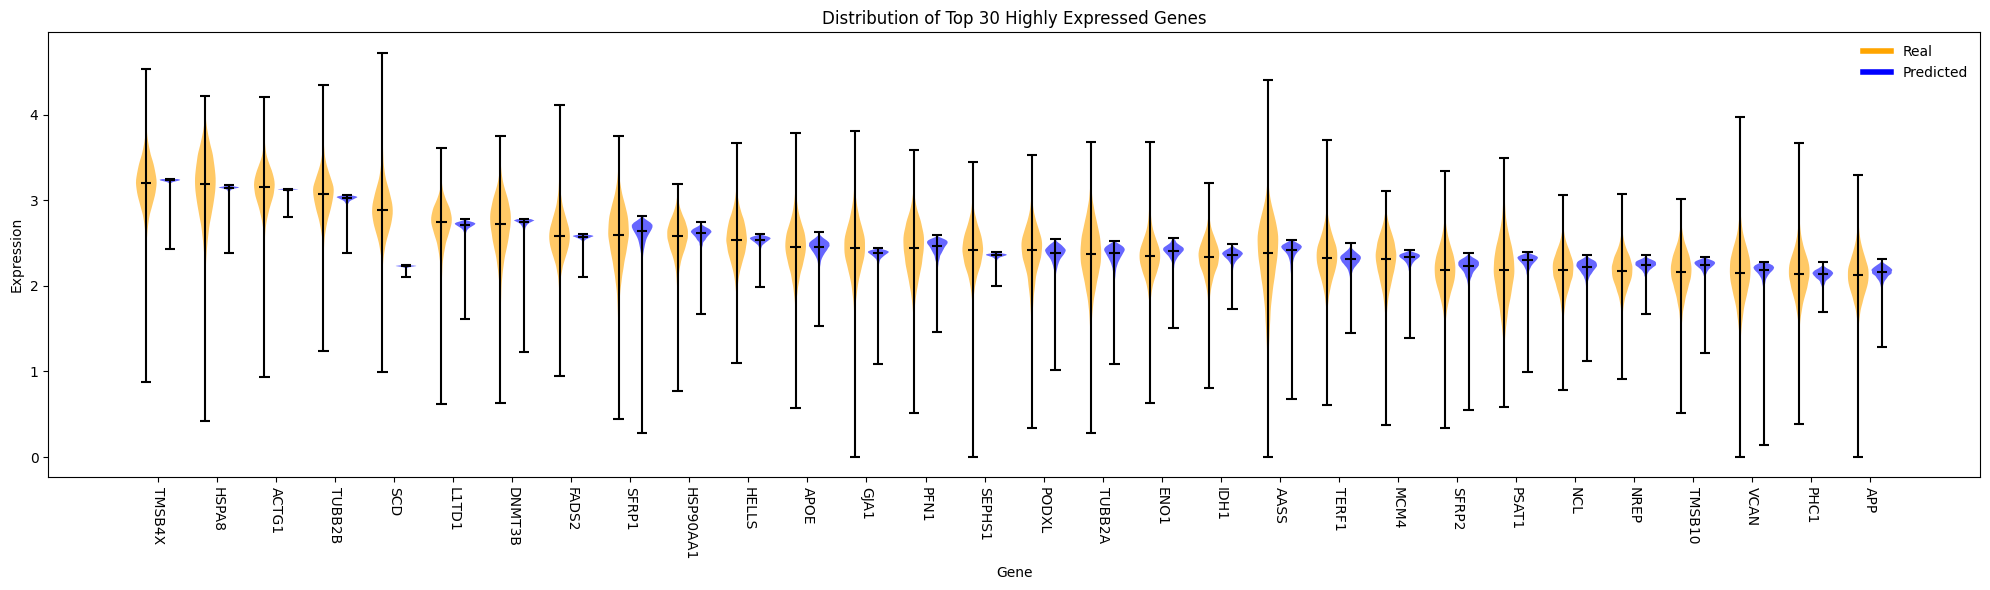

In [41]:
plot_top_highly_expressed_genes(30, real_adata[real_adata.obs['target_gene']!='non-targeting'], pred_adata[pred_adata.obs['target_gene']!='non-targeting'], False)

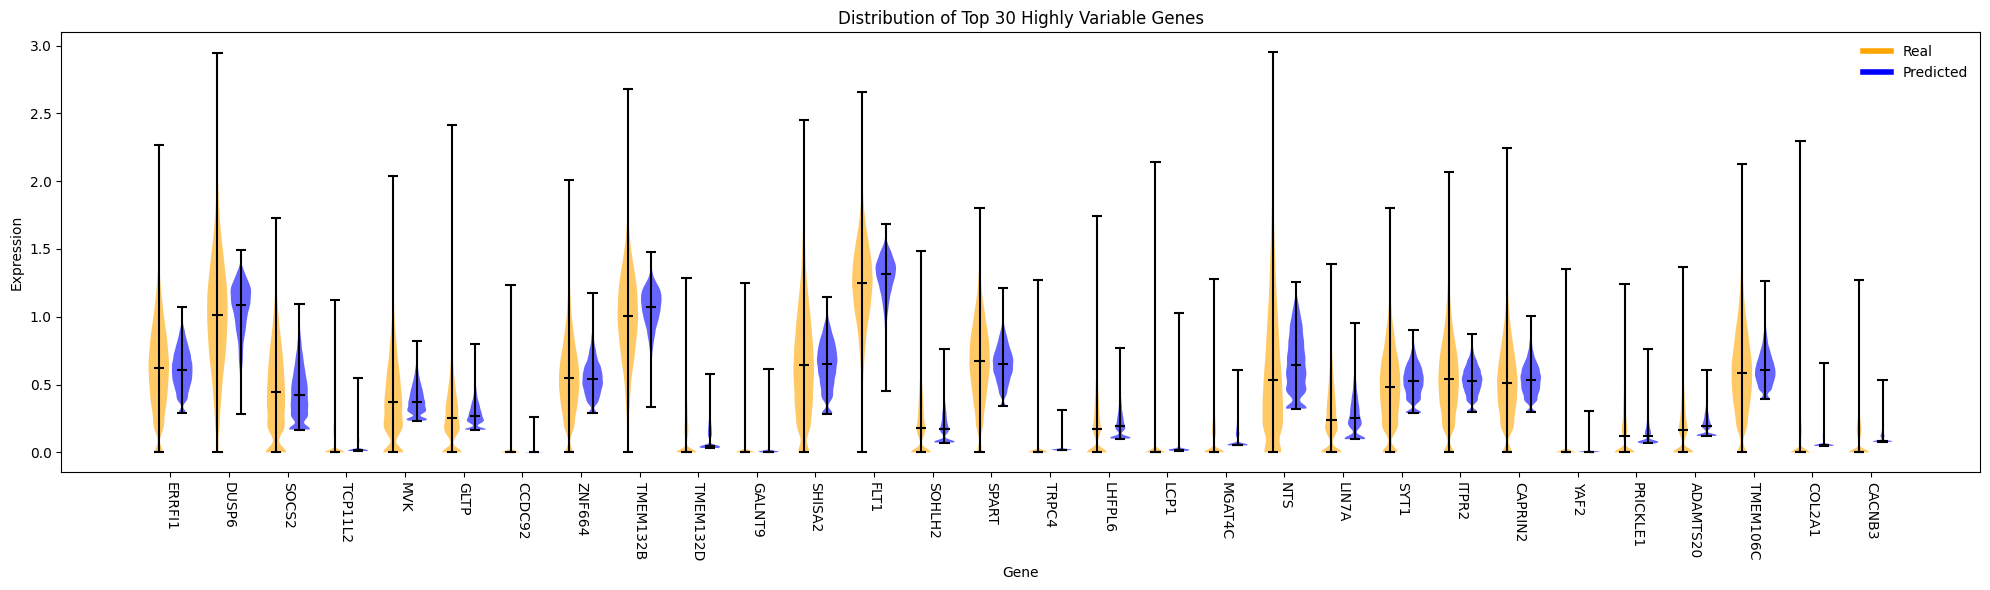

In [40]:
plot_top_highly_variable_genes(30, real_adata[real_adata.obs['target_gene']!='non-targeting'], pred_adata[pred_adata.obs['target_gene']!='non-targeting'], False)

In [32]:
pred_adata.obs['target_gene'].unique()

['PRCP', 'TADA1', 'TSC22D4', 'FOXH1', 'KLF10', ..., 'PMEL', 'KIF20A', 'SALL4', 'FDPS', 'non-targeting']
Length: 23
Categories (23, object): ['CDCA2', 'FDPS', 'FOXH1', 'HAT1', ..., 'XRCC4', 'ZNF426', 'ZNF562', 'non-targeting']

**let's try with just the DE genes**

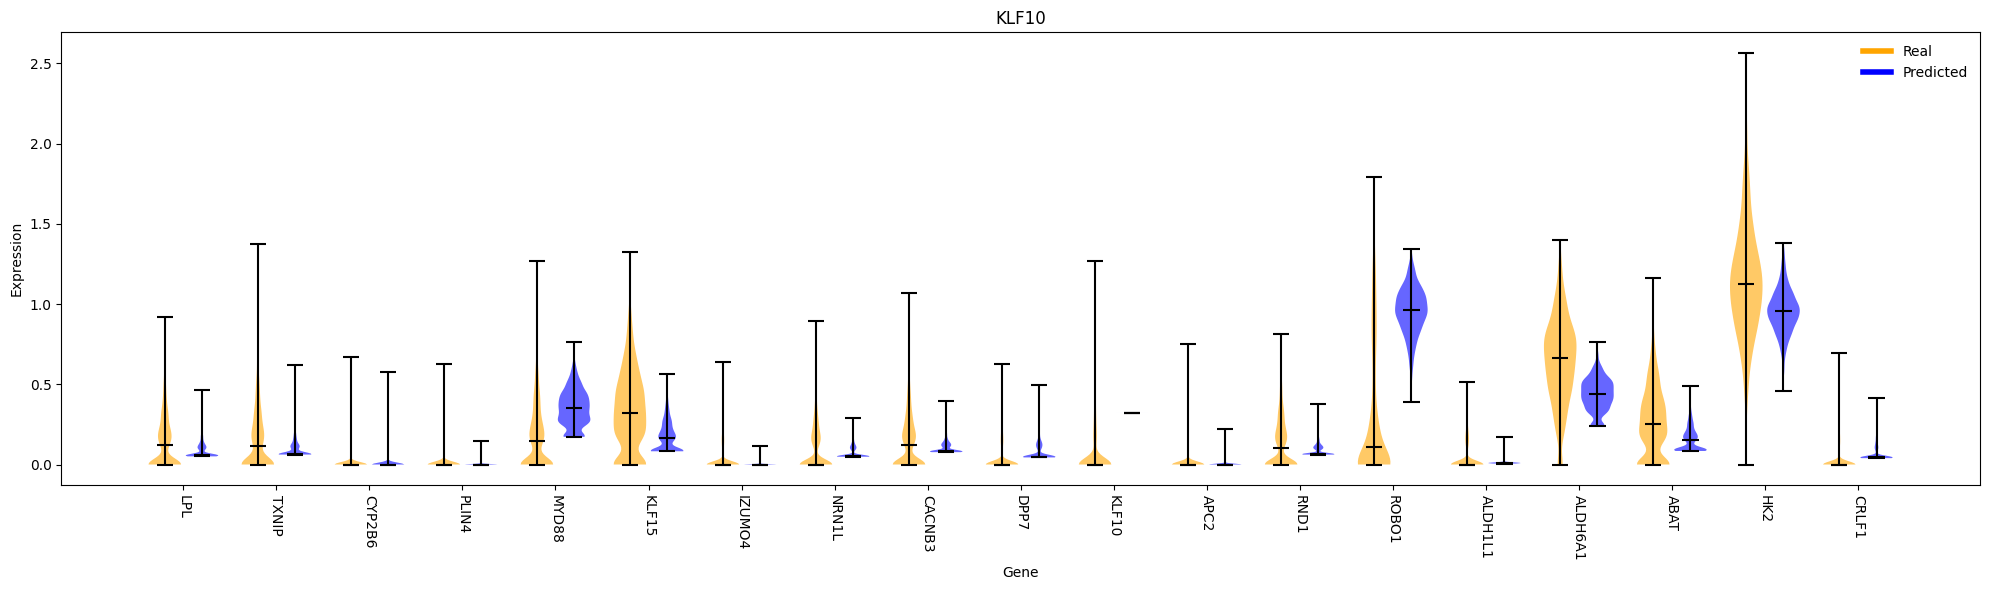

In [37]:
des_calculator = RobustDES(lfc_threshold=0.5, alpha=0.05)

max_de_genes = 20
perturb_label = 'KLF10'
DE_genes, _ = des_calculator.get_de_genes(real_adata, 'target_gene', perturb_label, 'non-targeting')
list_DE_genes = list(set(DE_genes.index))
if len(list_DE_genes)>max_de_genes:
    list_DE_genes = list(set(DE_genes.loc[DE_genes['logfoldchanges'].abs().sort_values(ascending=False).index[:max_de_genes]].index))

plot_violins_predictions_selected_genes(list_DE_genes, 
    real_adata[real_adata.obs['target_gene']==perturb_label], 
    pred_adata[pred_adata.obs['target_gene']==perturb_label], 
    False, 
    perturb_label
)

### **Attention network analysis**

In [33]:
config

{'project': {'name': 'SPECTRA_vcc_3layers',
  'seed': 42,
  'deterministic': False,
  'use_wandb': True},
 'data': {'adata_path': '/scratch/michele.calabro/gears/VCC/SPECTRA/data/adata_vcc.h5ad',
  'gene_list_path': '/scratch/michele.calabro/gears/VCC/SPECTRA/data/gene_list-vcc.txt',
  'network_path': '/scratch/michele.calabro/gears/VCC/SPECTRA/data/FUNGI_new_vcc.tsv',
  'scgpt_embeddings_path': '/scratch/michele.calabro/gears/VCC/SPECTRA/data/scGPT_embeddings_all_genes.pkl',
  'gene_weights_path': '/scratch/michele.calabro/gears/VCC/SPECTRA/data/gene_weights-vcc.pkl'},
 'model': {'architecture': 'reduced_encoder',
  'conv_type': 'FAGCN',
  'residual_weight': 0.7,
  'n_channels': 64,
  'dropout_p': 0.3,
  'num_node_features': 1},
 'training': {'batch_size': 16,
  'lr': 0.001,
  'n_epochs': 20,
  'alpha': 1.8,
  'beta': 0.01,
  'gamma': 2.6,
  'eta': 3.3,
  'test_ratio': 0.2,
  'val_ratio': 0.1}}

In [25]:
x,y,pert,pert_idx = next(iter(test_loader)) 

pert_idx[0]

tensor([75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75])

In [36]:
pert[0]

tensor([False, False, False,  ..., False, False, False])

In [29]:
idx_to_gene = {idx:gene for gene, idx in gene_to_idx.items()}

In [30]:
idx_to_gene.get(pert_idx[0].item())

'MYOM3'

In [35]:
target_gene = "PRDM14" 
model_config['pert_to_idx'][target_gene]

98

In [21]:
# Assuming you have loaded your trained model weights...
model.eval()

# Grab a single batch (e.g., TP53 knockouts) - NOTE: this is just an example
x,y,pert,pert_idx = next(iter(test_loader)) 

# Get the attention matrices
A_Agg, _, _ = model((x,pert), return_attention_weights=True)

# perturbation 
pert = pert[0]
index = torch.nonzero(pert).squeeze().numpy()
idx_to_gene = {idx:gene for gene, idx in gene_to_idx.items()}
perturbed_gene = idx_to_gene[index.item()]
print(perturbed_gene)
print('============')

# Shows where information originates from Node $i$ and travels to other nodes 
shockwaves={idx_to_gene[i]:A_Agg[index, i] for i in range(A_Agg.shape[0])}

# Inspect the shockwave - Sort keys by descending absolute value, take top 10
top_10_keys = sorted(shockwaves, 
                    key=lambda k: abs(shockwaves[k]), 
                    reverse=True)[:10]
top_10_dict = {k: shockwaves[k].item() for k in top_10_keys}
print(top_10_dict)

# building networkx digraph from adjacency matrix
attention_graph = nx.from_numpy_array(A_Agg.cpu().detach().numpy(), create_using=nx.DiGraph)
attention_graph = nx.relabel_nodes(attention_graph, idx_to_gene)
print(attention_graph.number_of_nodes())
print(attention_graph.number_of_edges())

PMS1
{'PLEKHN1': 0.0, 'ISG15': 0.0, 'AGRN': 0.0, 'ACAP3': 0.0, 'MXRA8': 0.0, 'CCNL2': 0.0, 'VWA1': 0.0, 'TMEM240': 0.0, 'MMP23B': 0.0, 'PRKCZ': 0.0}
4914
4323363


In [43]:
target_gene = "PRDM14"  # Change this to any perturbation you want to analyze

if target_gene not in gene_to_idx:
    raise ValueError(f"Gene '{target_gene}' not found in gene mapping.")
target_idx = gene_to_idx[target_gene]
idx_to_gene = {idx: gene for gene, idx in gene_to_idx.items()}

# ---------------------------------------------------------
# 2. FIND THE BATCH
# ---------------------------------------------------------
target_batch = None

# Iterate through the loader to find the specific perturbation
for x, y, pert, pert_idx in test_loader:
    # pert is shape [B, N]. Check if the target_idx is active (1.0)
    # Since batches contain unique perturbations, checking the first item is sufficient
    if pert[0, target_idx] > 0:
        target_batch = (x, y, pert, pert_idx)
        break

if target_batch is None:
    raise ValueError(f"Batch for perturbation '{target_gene}' not found in test_loader.")

x, y, pert, pert_idx = target_batch
x = x.to(model.device)
y = y.to(model.device)
pert = pert.to(model.device)

with torch.no_grad():
    A_Agg, _, _ = model((x, pert), return_attention_weights=True)

# perturbation 
pert = pert[0]
index = torch.nonzero(pert).squeeze().cpu().numpy()
idx_to_gene = {idx:gene for gene, idx in gene_to_idx.items()}
perturbed_gene = idx_to_gene[index.item()]
print(perturbed_gene)
print('============')

# Shows where information originates from Node $i$ and travels to other nodes 
shockwaves={idx_to_gene[i]:A_Agg[index, i] for i in range(A_Agg.shape[0])}

# Inspect the shockwave - Sort keys by descending absolute value, take top 10
top_10_keys = sorted(shockwaves, 
                    key=lambda k: abs(shockwaves[k]), 
                    reverse=True)[:10]
top_10_dict = {k: shockwaves[k].item() for k in top_10_keys}
print(top_10_dict)

# building networkx digraph from adjacency matrix
attention_graph = nx.from_numpy_array(A_Agg.cpu().detach().numpy(), create_using=nx.DiGraph)
attention_graph = nx.relabel_nodes(attention_graph, idx_to_gene)
print(attention_graph.number_of_nodes())
print(attention_graph.number_of_edges())

PRDM14
{'SHROOM3': -144.0431365966797, 'EHD3': -119.85809326171875, 'NDRG1': -115.91751098632812, 'CYP2C8': -108.95059204101562, 'NR5A1': -105.6991195678711, 'LTBP1': -100.89456176757812, 'TRPV6': -100.88563537597656, 'FAM102B': -98.00518798828125, 'TM4SF1': -97.61615753173828, 'CCDC121': -97.50143432617188}
4914
17133322


Total non-zero edges: 169075
Max attention weight: 1.000000
Min attention weight: -0.194254
Median attention weight: 0.018868
95th percentile: 0.055556


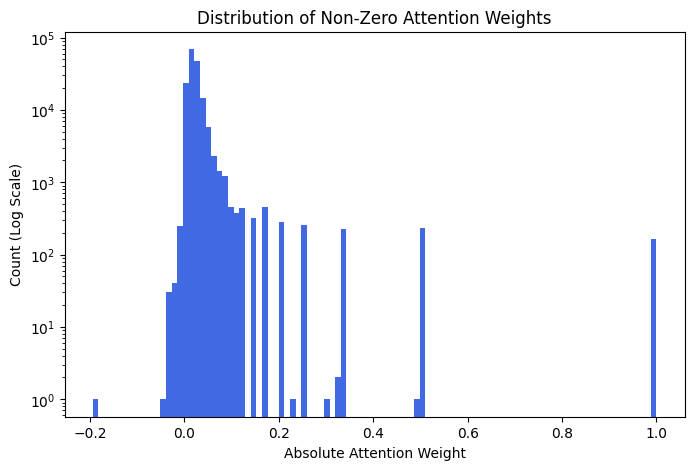

In [36]:
import matplotlib.pyplot as plt
import numpy as np

A_dense = A_1hop.cpu().detach().numpy()
# Flatten and get absolute values of only the non-zero edges
non_zero_weights = A_dense[A_dense != 0.]

print(f"Total non-zero edges: {len(non_zero_weights)}")
print(f"Max attention weight: {non_zero_weights.max():.6f}")
print(f"Min attention weight: {non_zero_weights.min():.6f}")
print(f"Median attention weight: {np.median(non_zero_weights):.6f}")
print(f"95th percentile: {np.percentile(non_zero_weights, 95):.6f}")

plt.figure(figsize=(8, 5))
# Using a log scale because usually 99% of weights are microscopic
plt.hist(non_zero_weights, bins=100, color='royalblue', log=True)
plt.title("Distribution of Non-Zero Attention Weights")
plt.xlabel("Absolute Attention Weight")
plt.ylabel("Count (Log Scale)")
plt.show()

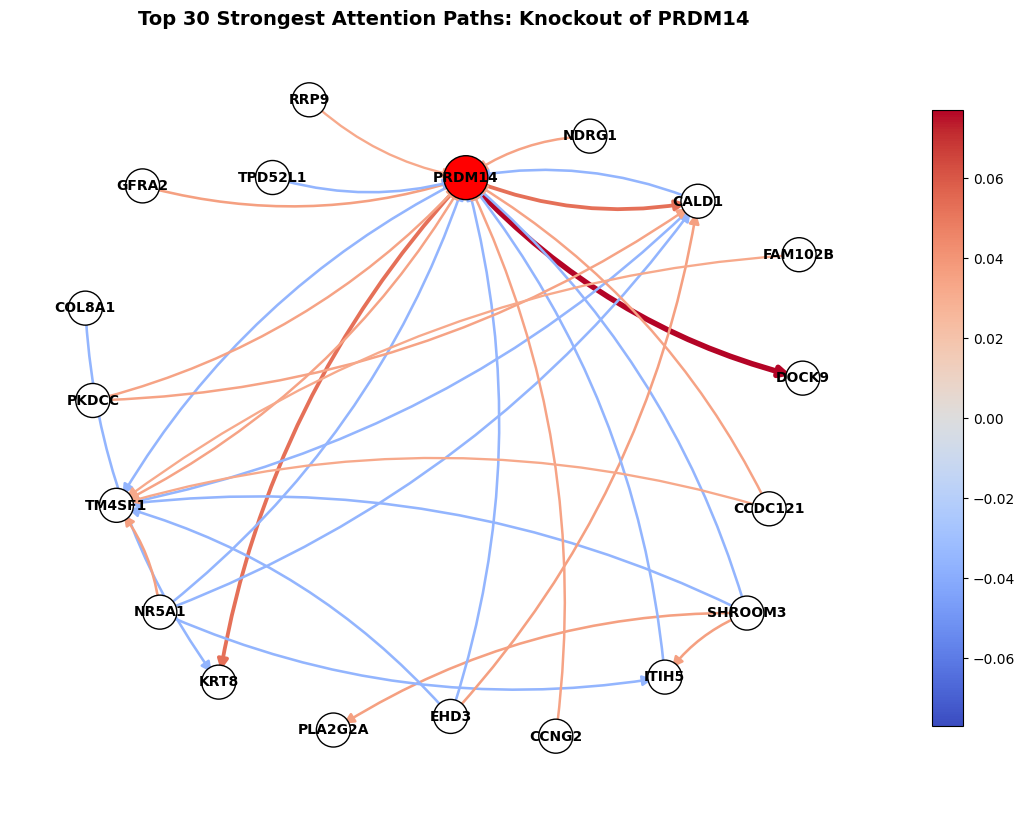

In [37]:
# Global noise floor (keeps graph building fast)
minimum_signal = 1e-6
A_dense[np.abs(A_dense) < minimum_signal] = 0.0

attention_graph = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)
attention_graph = nx.relabel_nodes(attention_graph, idx_to_gene)

# NOTE: rimotion of self-loops
attention_graph.remove_edges_from(nx.selfloop_edges(attention_graph))


# Extract Ego-Graph
try:
    subgraph = nx.ego_graph(attention_graph, perturbed_gene, radius=1, center=True)
except nx.NodeNotFound:
    print(f"Node {perturbed_gene} has no edges above the noise floor.")
    subgraph = nx.DiGraph()

if len(subgraph.nodes) > 1:
    K_edges = 30
    
    # 3. STORE BOTH SIGNED AND ABSOLUTE WEIGHTS
    edges_with_weights = [
        (u, v, data['weight'], abs(data['weight'])) 
        for u, v, data in subgraph.edges(data=True)
    ]
    
    # Sort strictly by the ABSOLUTE magnitude to find the strongest signals
    edges_with_weights.sort(key=lambda x: x[3], reverse=True)
    top_edges = edges_with_weights[:K_edges]
    
    clean_subgraph = nx.DiGraph()
    for u, v, w, abs_w in top_edges:
        clean_subgraph.add_edge(u, v, weight=w, abs_weight=abs_w)
    
    # 4. Visualization Setup
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(clean_subgraph, k=0.8, seed=42)
    
    # Highlight perturbed node in bold RED, targets in muted GRAY
    node_colors = ["red" if node == perturbed_gene else "white" for node in clean_subgraph.nodes()]
    node_sizes = [1000 if node == perturbed_gene else 600 for node in clean_subgraph.nodes()]
    
    nx.draw_networkx_nodes(clean_subgraph, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black')
    nx.draw_networkx_labels(clean_subgraph, pos, font_size=10, font_weight="bold")
    
    # 5. DYNAMIC EDGE STYLING
    signed_weights = [w for _, _, w, _ in top_edges]
    abs_weights = [abs_w for _, _, _, abs_w in top_edges]
    max_abs_w = max(abs_weights) if abs_weights else 1.0
    edge_widths = [(abs_w / max_abs_w) * 4. for abs_w in abs_weights]
    
    # Create a symmetric color scale centered exactly at 0
    vmin = -max_abs_w
    vmax = max_abs_w
    cmap = plt.cm.coolwarm
    
    edge_draw = nx.draw_networkx_edges(
        clean_subgraph, pos, 
        width=edge_widths, 
        edge_color=signed_weights, 
        edge_cmap=cmap,
        edge_vmin=vmin,    # Locks the bottom of the colormap to the negative max
        edge_vmax=vmax,    # Locks the top of the colormap to the positive max
        arrowsize=15, 
        connectionstyle='arc3,rad=0.15' # Increased curve to separate bidirectional arrows
    )
    
    # Add Colorbar matched to the diverging scale
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8)
    #cbar.set_label("Attention Flow (Blue = Negative, Red = Positive)", fontsize=12)
    
    plt.title(f"Top {K_edges} Strongest Attention Paths: Knockout of {perturbed_gene}", fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()
else:
    print("Not enough local downstream nodes found.")

In [ ]:
# Global noise floor (keeps graph building fast)
minimum_signal = 1e-1
A_dense[np.abs(A_dense) < minimum_signal] = 0.0

attention_graph = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)
attention_graph = nx.relabel_nodes(attention_graph, idx_to_gene)

# NOTE: rimotion of self-loops
attention_graph.remove_edges_from(nx.selfloop_edges(attention_graph))


# Extract Ego-Graph
try:
    subgraph = nx.ego_graph(attention_graph, perturbed_gene, radius=1, center=True)
except nx.NodeNotFound:
    print(f"Node {perturbed_gene} has no edges above the noise floor.")
    subgraph = nx.DiGraph()

if len(subgraph.nodes) > 1:
    K_total = 30
    K_direct_minimum = 15 # Guarantee at least 15 edges touch the perturbed gene
    
    direct_edges = []
    indirect_edges = []
    
    # Separate edges into those touching the ego node, and those that don't
    for u, v, data in subgraph.edges(data=True):
        edge_tuple = (u, v, data['weight'], abs(data['weight']))
        if u == perturbed_gene or v == perturbed_gene:
            direct_edges.append(edge_tuple)
        else:
            indirect_edges.append(edge_tuple)
            
    # Sort both pools by absolute magnitude
    direct_edges.sort(key=lambda x: x[3], reverse=True)
    indirect_edges.sort(key=lambda x: x[3], reverse=True)
    
    # Secure the protected direct edges
    selected_direct = direct_edges[:K_direct_minimum]
    
    # Throw the leftover direct edges back into the general pool
    remaining_pool = direct_edges[K_direct_minimum:] + indirect_edges
    remaining_pool.sort(key=lambda x: x[3], reverse=True)
    
    # Fill the rest of the quota with the strongest remaining edges
    remaining_quota = K_total - len(selected_direct)
    selected_indirect = remaining_pool[:remaining_quota]
    
    # Combine to form our final Top K list
    top_edges = selected_direct + selected_indirect
    
    clean_subgraph = nx.DiGraph()
    for u, v, w, abs_w in top_edges:
        clean_subgraph.add_edge(u, v, weight=w, abs_weight=abs_w)
    
    # 4. Visualization Setup
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(clean_subgraph, k=0.8, seed=42)
    
    # Highlight perturbed node in bold RED, targets in muted GRAY
    node_colors = ["red" if node == perturbed_gene else "white" for node in clean_subgraph.nodes()]
    node_sizes = [1000 if node == perturbed_gene else 600 for node in clean_subgraph.nodes()]
    
    nx.draw_networkx_nodes(clean_subgraph, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black')
    
    label_pos = {}
    shift_amount = 0.05 # Adjust this number if the labels are too far or too close
    for node, (x, y) in pos.items():
        label_pos[node] = (x, y - shift_amount)
    nx.draw_networkx_labels(clean_subgraph, label_pos, font_size=9, font_weight="bold")
    
    # 5. DYNAMIC EDGE STYLING
    signed_weights = [w for _, _, w, _ in top_edges]
    abs_weights = [abs_w for _, _, _, abs_w in top_edges]
    max_abs_w = max(abs_weights) if abs_weights else 1.0
    edge_widths = [(abs_w / max_abs_w) * 4. for abs_w in abs_weights]
    
    # Create a symmetric color scale centered exactly at 0
    vmin = -max_abs_w
    vmax = max_abs_w
    cmap = plt.cm.coolwarm
    
    edge_draw = nx.draw_networkx_edges(
        clean_subgraph, pos, 
        width=edge_widths, 
        edge_color=signed_weights, 
        edge_cmap=cmap,
        edge_vmin=vmin,    # Locks the bottom of the colormap to the negative max
        edge_vmax=vmax,    # Locks the top of the colormap to the positive max
        arrowsize=15, 
        connectionstyle='arc3,rad=0.15' # Increased curve to separate bidirectional arrows
    )
    
    # Add Colorbar matched to the diverging scale
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8)
    #cbar.set_label("Attention Flow (Blue = Negative, Red = Positive)", fontsize=12)
    
    plt.title(f"Top {K_edges} Strongest Attention Paths: Knockout of {perturbed_gene}", fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()
else:
    print("Not enough local downstream nodes found.")

***
fixed stuff (maybe)

In [22]:
list_interesting_perturbations = [
    'POU5F1',
    'SOX2',
    'NANOG',
    'TDGF1',
    'SMAD2/3',
    'FGFR1',
    'DNMT3B',
    'TP53',
    'BMP4',
    'CTNNB1',
    'PRDM14',
    'LIN28A',
    'OCT4'
]

In [ ]:
intersection = list(set(pred_adata.obs['target_gene'].unique().tolist()) & set(list_interesting_perturbations))
print(intersection)

In [ ]:
def downstream_A_from_alpha(edge_index, alpha, N, edge_weight=None):
    """
    Builds A[src, dst] for original directed edges src -> dst.
    This is row-source / column-target convention.
    """
    src, dst = edge_index

    deg_in = torch.bincount(dst, minlength=N).float().clamp_min(1.0).to(alpha.device)

    vals = alpha / deg_in[dst]

    if edge_weight is not None:
        vals = vals * edge_weight.to(alpha.device)

    A = torch.sparse_coo_tensor(
        torch.stack([src, dst]),
        vals,
        (N, N),
        device=alpha.device
    ).to_dense()

    return A

@torch.no_grad()
def compute_downstream_path_matrix(model, x, pert):
    y_hat, x_hat, (a1, a2, a3) = model.forward((x, pert), return_attention_weights=True)

    B = pert.shape[0]
    N = model.num_nodes
    E = model.edge_index.shape[1]

    alpha1 = a1["alpha_in"].view(B, E)
    alpha2 = a2["alpha_in"].view(B, E)
    alpha3 = a3["alpha_in"].view(B, E)

    A_sum = torch.zeros(N, N, device=model.device)

    for b in range(B):
        A1 = downstream_A_from_alpha(model.edge_index, alpha1[b], N)
        A2 = downstream_A_from_alpha(model.edge_index, alpha2[b], N)
        A3 = downstream_A_from_alpha(model.edge_index, alpha3[b], N)

        # row = origin gene, col = destination gene
        A_sum += A1 @ A2 @ A3

    A_Agg = A_sum / B
    return A_Agg, y_hat, x_hat

@torch.no_grad()
def compute_downstream_path_matrices(model, x, pert):
    model.eval()

    y_hat, x_hat, (a1, a2, a3) = model(
        (x, pert),
        return_attention_weights=True
    )

    B = pert.shape[0]
    N = model.num_nodes
    E = model.edge_index.shape[1]

    alpha1 = a1["alpha_in"].view(B, E)
    alpha2 = a2["alpha_in"].view(B, E)
    alpha3 = a3["alpha_in"].view(B, E)

    A1_sum = torch.zeros(N, N, device=model.device)
    A12_sum = torch.zeros(N, N, device=model.device)
    A123_sum = torch.zeros(N, N, device=model.device)

    for b in range(B):
        A1 = downstream_A_from_alpha(model.edge_index, alpha1[b], N)
        A2 = downstream_A_from_alpha(model.edge_index, alpha2[b], N)
        A3 = downstream_A_from_alpha(model.edge_index, alpha3[b], N)

        A12 = A1 @ A2
        A123 = A12 @ A3

        A1_sum += A1
        A12_sum += A12
        A123_sum += A123

    return {
        "one_hop": A1_sum / B,
        "two_hops": A12_sum / B,
        "three_hops": A123_sum / B
    }, y_hat, x_hat

one_hop
4914
169061
two_hops
4914
3579135
three_hops
4914
3538568


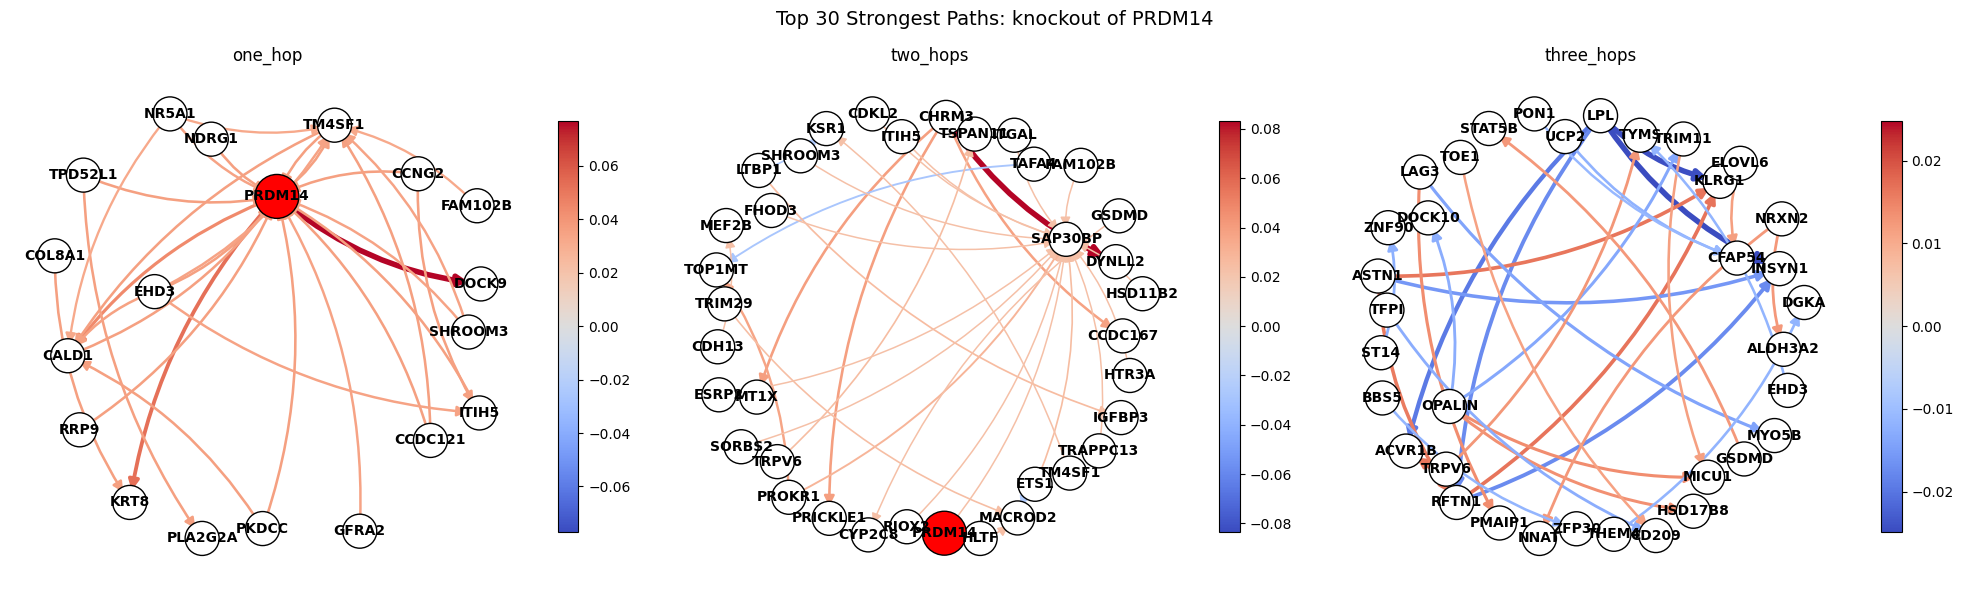

In [54]:
from matplotlib import pyplot as plt

minimum_signal = 1e-4
K_edges = 30

# perturbation to analyze
target_gene = "PRDM14" 
if target_gene not in gene_to_idx:
    raise ValueError(f"Gene '{target_gene}' not found in gene mapping.")
target_idx = gene_to_idx[target_gene]

# Iterate batches through the loader to find the specific perturbation
# target_batch = None
# for x, y, pert, pert_idx in test_loader:
#     if pert[0, target_idx] > 0:
#         target_batch = (x, y, pert, pert_idx)
#         break
for x, y, pert, pert_idx in test_loader:
    if pert_idx[0].item() == model_config['pert_to_idx'][target_gene]:
        target_batch = (x, y, pert, pert_idx)
        break

if target_batch is None:
    raise ValueError(f"Batch for perturbation '{target_gene}' not found in test_loader.")


x, y, pert, pert_idx = target_batch
x = x.to(model.device)
y = y.to(model.device)
pert = pert.to(model.device)

model.eval()

A_Agg, _, _ = compute_downstream_path_matrices(model, x, pert)

idx_to_gene = {idx:gene for gene, idx in gene_to_idx.items()}
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Top {K_edges} Strongest Paths: knockout of {target_gene}', fontsize=14)
cmap = plt.cm.coolwarm

for i, current_hop in enumerate(A_Agg.keys()):

    A = A_Agg[current_hop]
    A_dense = A.cpu().detach().numpy()
    A_dense[np.abs(A_dense) < minimum_signal] = 0.0

    # # Inspect the shockwave - Sort keys by descending absolute value, take top 10
    # # Shows where information originates from Node $i$ and travels to other nodes 
    # shockwaves={idx_to_gene[i]:A_1hop[index, i] for i in range(A_1hop.shape[0])}
    # top_10_keys = sorted(shockwaves, 
    #                     key=lambda k: abs(shockwaves[k]), 
    #                     reverse=True)[:10]
    # top_10_dict = {k: shockwaves[k].item() for k in top_10_keys}
    # print(top_10_dict)

    # building networkx digraph from adjacency matrix
    attention_graph = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)
    attention_graph = nx.relabel_nodes(attention_graph, idx_to_gene)

    # NOTE: rimotion of self-loops
    attention_graph.remove_edges_from(nx.selfloop_edges(attention_graph))

    print('====================')
    print(current_hop)
    print(attention_graph.number_of_nodes())
    print(attention_graph.number_of_edges())
    print('====================')

    # Extract Ego-Graph
    try:
        subgraph = nx.ego_graph(attention_graph, target_gene, radius=1, center=True)
    except nx.NodeNotFound:
        print(f"Node {perturbed_gene} has no edges above the noise floor.")
        subgraph = nx.DiGraph()


    if len(subgraph.nodes) > 1:
        
        # store signed and absolute weights
        edges_with_weights = [
            (u, v, data['weight'], abs(data['weight'])) 
            for u, v, data in subgraph.edges(data=True)
        ]
        
        # Sort strictly by the absolute magnitude to find the strongest signals
        edges_with_weights.sort(key=lambda x: x[3], reverse=True)
        top_edges = edges_with_weights[:K_edges]
        
        clean_subgraph = nx.DiGraph()
        for u, v, w, abs_w in top_edges:
            clean_subgraph.add_edge(u, v, weight=w, abs_weight=abs_w)
        
        # Visualization Setup
        pos = nx.spring_layout(clean_subgraph, k=0.7, seed=42)
        node_colors = ["red" if node == target_gene else "white" for node in clean_subgraph.nodes()]
        node_sizes = [1000 if node == target_gene else 600 for node in clean_subgraph.nodes()]
        nx.draw_networkx_nodes(clean_subgraph, pos, ax=axes[i], node_color=node_colors, node_size=node_sizes, edgecolors='black')
        nx.draw_networkx_labels(clean_subgraph, pos, ax=axes[i], font_size=10, font_weight="bold")
        
        # dynamic edge syling
        signed_weights = [w for _, _, w, _ in top_edges]
        abs_weights = [abs_w for _, _, _, abs_w in top_edges]
        max_abs_w = max(abs_weights) if abs_weights else 1.0
        edge_widths = [(abs_w / max_abs_w) * 4. for abs_w in abs_weights]
        vmin = -max_abs_w
        vmax = max_abs_w
        
        edge_draw = nx.draw_networkx_edges(
            clean_subgraph, pos, 
            ax=axes[i],
            width=edge_widths, 
            edge_color=signed_weights, 
            edge_cmap=cmap,
            edge_vmin=vmin,    # Locks the bottom of the colormap to the negative max
            edge_vmax=vmax,    # Locks the top of the colormap to the positive max
            arrowsize=15, 
            connectionstyle='arc3,rad=0.15' # Increased curve to separate bidirectional arrows
        )
        
        # Add Colorbar matched to the diverging scale
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
        sm.set_array([])
        #cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8)
        fig.colorbar(sm, ax=axes[i], shrink=0.8)
        axes[i].set_title(f"{current_hop}")
        #cbar.set_label("Attention Flow (Blue = Negative, Red = Positive)", fontsize=12)
        
        axes[i].set_axis_off()
    else:
        print("Not enough local downstream nodes found.")

plt.tight_layout()
plt.show()
    

    


In [ ]:
# Global noise floor (keeps graph building fast)
minimum_signal = 1e-4
A_dense[np.abs(A_dense) < minimum_signal] = 0.0

attention_graph = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)
attention_graph = nx.relabel_nodes(attention_graph, idx_to_gene)

# NOTE: rimotion of self-loops
attention_graph.remove_edges_from(nx.selfloop_edges(attention_graph))


# Extract Ego-Graph
try:
    subgraph = nx.ego_graph(attention_graph, perturbed_gene, radius=1, center=True)
except nx.NodeNotFound:
    print(f"Node {perturbed_gene} has no edges above the noise floor.")
    subgraph = nx.DiGraph()

if len(subgraph.nodes) > 1:
    K_edges = 30
    
    # 3. STORE BOTH SIGNED AND ABSOLUTE WEIGHTS
    edges_with_weights = [
        (u, v, data['weight'], abs(data['weight'])) 
        for u, v, data in subgraph.edges(data=True)
    ]
    
    # Sort strictly by the ABSOLUTE magnitude to find the strongest signals
    edges_with_weights.sort(key=lambda x: x[3], reverse=True)
    top_edges = edges_with_weights[:K_edges]
    
    clean_subgraph = nx.DiGraph()
    for u, v, w, abs_w in top_edges:
        clean_subgraph.add_edge(u, v, weight=w, abs_weight=abs_w)
    
    # 4. Visualization Setup
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(clean_subgraph, k=0.8, seed=42)
    
    # Highlight perturbed node in bold RED, targets in muted GRAY
    node_colors = ["red" if node == perturbed_gene else "white" for node in clean_subgraph.nodes()]
    node_sizes = [1000 if node == perturbed_gene else 600 for node in clean_subgraph.nodes()]
    
    nx.draw_networkx_nodes(clean_subgraph, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black')
    nx.draw_networkx_labels(clean_subgraph, pos, font_size=10, font_weight="bold")
    
    # 5. DYNAMIC EDGE STYLING
    signed_weights = [w for _, _, w, _ in top_edges]
    abs_weights = [abs_w for _, _, _, abs_w in top_edges]
    max_abs_w = max(abs_weights) if abs_weights else 1.0
    edge_widths = [(abs_w / max_abs_w) * 4. for abs_w in abs_weights]
    
    # Create a symmetric color scale centered exactly at 0
    vmin = -max_abs_w
    vmax = max_abs_w
    cmap = plt.cm.coolwarm
    
    edge_draw = nx.draw_networkx_edges(
        clean_subgraph, pos, 
        width=edge_widths, 
        edge_color=signed_weights, 
        edge_cmap=cmap,
        edge_vmin=vmin,    # Locks the bottom of the colormap to the negative max
        edge_vmax=vmax,    # Locks the top of the colormap to the positive max
        arrowsize=15, 
        connectionstyle='arc3,rad=0.15' # Increased curve to separate bidirectional arrows
    )
    
    # Add Colorbar matched to the diverging scale
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8)
    #cbar.set_label("Attention Flow (Blue = Negative, Red = Positive)", fontsize=12)
    
    plt.title(f"Top {K_edges} Strongest Attention Paths: Knockout of {perturbed_gene}", fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()
else:
    print("Not enough local downstream nodes found.")